## Anomaly Detection & Time Series |


Question 1: What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.
  - Anomaly Detection is a technique in Machine Learning used to identify data points or patterns that deviate significantly from normal behavior. These unusual patterns are called anomalies or outliers, and they often indicate critical events like fraud, system failures, or errors.
  - Types of Anomailes:
    -  Point Anomalies(Global Anomalies)
       - A single data point is considered anomalous compared to the rest of the data.
       - Example: -->> In a dataset of daily temperature (20c-30c), a value of 50c is clearly unusual.
       - Real-world case: -->> In credit card transactions, a 1,00,000 purchase when you usually spend 1,000.
    - Contextual Anomalies(conditional Anomalies)
      - A data point is anomolus is a specific context, but may be normal in another.
      - Example: -->> Temperature of 15c
        - Normal in winter
        - Anomalous in summer
      - Real world case: -->> High electricity usage at night might be suspecious, but normal during daytime working hours.
    - Collective Anomalies
      - A group of data points together is anomalous, even if individual points may appear normal.
      - Example: -->> A sudden sequence of small but continous network request could indicate a cyber attack, even if each request looks normal.
      - Real-world case: -->> In ECG data, a series of slightly irregular heartbeats together may indicate a medical condition, though each beat alone seems fine.       

Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
  - Isolation Forest, DBSCAN, and Local Outlier Factor (LOF) are all popular unsupervised learning algorithms for anomaly detection, but they view "outlierness", while the other two use density in distinct ways.
  - Isolation Forest :      
    - Instead of modeling "normal" data points to find what doesn't fit, IF explicitly targets anomalies. It works on the principle that anomalies are few and different.
      - It builds an ensemble of random decision trees.
      - For each tree, it randomly selects a feature and a random split value.
      - The Logic: Anomalies are usually located far from dense clusters, so they require fewer splits to be isolated.
      - Score: The shorter the average path length from the root to the leaf node, the higher the probability that the point is an outlier.
    - Suitable usecase :       
      - Suitable Use CasesHigh-Dimensional Data: It performs exceptionally well when you have many features.
      - Large Datasets: It is computationally efficient ($O(n)$) because it doesn't require distance calculations between points.
      - Global Outliers: Best for finding points that are distinct from the entire dataset as a whole.
  - DBSCAN (Density Based Spatial Clustering of Application with NOise):
    - Approach: Density-Based Clustering
    - DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is primarily a clustering algorithm that treats anomalies as "noise."
      - It groups together points that are close to each other based on a distance measurement ($\epsilon$) and a minimum number of points ($MinPts$).
      - The Logic: Points that do not belong to any cluster (because they are in low-density regions) are labeled as -1 or noise.
      - Parameters: It requires careful tuning of $\epsilon$. If $\epsilon$ is too small, everything looks like an outlier; if it's too large, outliers get swallowed into clusters.
    - Suitable case:
      - Spatial Data: Excellent for geographic or 2D/3D coordinate data
      - Non-Spherical Clusters: Unlike K-Means, it can find clusters of any shape (e.g., U-shapes, rings).
      - Filtering Noise: Useful when you want to "clean" a dataset by removing everything that isn't part of a significant group.
  - Local Outlier Factor (LOF)
    - Approach: Local Density
    - LOF is a more nuanced density-based approach. While DBSCAN looks at global density (using one $\epsilon$ for everyone), LOF looks at relative density.
      - It compares the density of a point to the density of its $k$-nearest neighbors.
      - The Logic: An outlier is a point whose local density is significantly lower than that of its neighbors.
      - Score: A score of $\approx 1$ means the point has similar density to its neighbors (normal). A score significantly $> 1$ indicates an outlier.
    - Suitable usecase case:
      - Varying Densities: Ideal for datasets where "normal" behavior in one cluster is much denser than "normal" behavior in another.
      - Local Anomalies: Best for finding the "odd one out" in a specific neighborhood, even if that point wouldn't look like an outlier on a global scale.            


Question 3: What are the key components of a Time Series? Explain each with one
example.
  - A Time Series is essentially a sequence of data points indexed in time order. To analyze it effectively, we break it down into four fundamental components (often called Decomposition).
   - 1. Trend ($T_t$)
    - The Trend represents the long-term increase or decrease in the data over a significant period. It ignores short-term fluctuations and shows the general "direction" the data is moving.
    - Example: The global increase in e-commerce sales over the last decade. While sales might dip in a specific month, the multi-year trajectory is consistently upward due to digital adoption.
  - 2. Seasonality ($S_t$)
    - Seasonality refers to patterns that repeat at fixed, predictable intervals within a year (e.g., daily, weekly, monthly, or quarterly). These are usually driven by the calendar or weather.
    - Example: A massive spike in retail toy sales every December due to Christmas. This pattern repeats every 12 months like clockwork.
  - 3.  Cyclical ($C_t$)
    - The Cyclical component refers to fluctuations that occur over a long duration (usually more than a year) but do not have a fixed, predictable period. These are often tied to economic or business cycles.
    - Example: The Real Estate market cycles. Housing prices may rise for several years (boom) and then stagnate or fall (recession) over a 5-10 year span. Unlike seasonality, you can’t predict the exact date the cycle will flip.       
  -  Irregular / Residual / Noise ($I_t$)
     - This component consists of unpredictable, random fluctuations that cannot be attributed to trend, cycle, or seasonality. These are often caused by "shocks" or one-time events.
     - Example: A sudden drop in airline stock prices due to an unexpected natural disaster or a global pandemic. These events are "one-offs" and don't follow a pattern.  

        - Mathematical Representation
        - In practice, these components are combined in two main ways:
        - Additive Model: $Y_t = T_t + S_t + C_t + I_t$(Used when the seasonal variation is constant over time.)
        - Multiplicative Model: $Y_t = T_t \times S_t \times C_t \times I_t$

Question 4: Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?
  - In time series analysis, a Stationary series is one whose statistical properties do not change over time. For a series to be considered "strictly stationary," its mean, variance, and covariance must remain constant regardless of when you measure them.
  - Think of it like this: if you take a "snapshot" of the data at two different time intervals, they should look statistically identical.
    - Criteria for Stationarity
      - For a time series $\{y_t\}$ to be stationary (specifically "weakly stationary"), it must satisfy three conditions:
      - Constant Mean: The average value remains stable over time ($E[y_t] = \mu$).
      - Constant Variance: The data does not get more or less volatile over time ($Var(y_t) = \sigma^2$).
      - Constant Autocovariance: The correlation between $y_t$ and $y_{t-k}$ depends only on the lag $k$, not on the time $t$.
    -  How to Test for Stationarity
    - You can check for stationarity using visual or statistical methods:
      - Visual Inspection (ADF Plot): Look at the plot. If you see a clear upward/downward trend or seasonal waves, it is non-stationary.
      - Augmented Dickey-Fuller (ADF) Test: This is the most common statistical test.
        - Null Hypothesis ($H_0$): The series has a unit root (is non-stationary).
        - Alternate Hypothesis ($H_1$): The series is stationary.
        - Decision: If $p\text{-value} \leq 0.05$, we reject $H_0$ and conclude the series is stationary.
      - KPSS Test: The opposite of ADF. Here, the null hypothesis is that the series is stationary.
  - How to Transform Non-Stationary to Stationary
    - If your data fails the tests above, you must transform it before applying models like ARIMA.
    - A. Differencing (To remove Trend)
      - This is the most common method. You subtract the current value from the previous value.$$y'_t = y_t - y_{t-1}$$
      - If the first difference doesn't work, you can apply a second difference ($y''_t = y'_t - y'_{t-1}$).       
    - B. Log Transformation (To stabilize Variance)
      - If the variance of your series increases over time (the "waves" get bigger), taking the natural log or square root of the data can dampen the fluctuations and make the variance constant.
    - C. Seasonal Differencing (To remove Seasonality)
      - If the pattern repeats every year, you subtract the value from the same season in the previous year.$$y'_t = y_t - y_{t-m}$$
      - (where $m$ is the number of seasons, e.g., 12 for monthly data).  


Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.
  - 1. AR (Autoregressive) Model
    - Structure
      - An AR model predicts future behavior based entirely on past behavior. It assumes that the current value is a linear combination of its own prior values (lags) plus a random error.
      - Parameter: $p$ (the number of past lags used).
      - Equation:$$Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \dots + \phi_p Y_{t-p} + \epsilon_t$$(where $c$ is a constant, $\phi$ represents the coefficients, and $\epsilon_t$ is white noise).
    - Application
      - Best for data where past momentum drives the future, such as short-term stock price movements where yesterday's price heavily influences today's price.
  - 2. MA (Moving Average) Model
    - Structure
      - Instead of using past values of the variable itself, an MA model uses past forecast errors (residuals) to predict the current value. It models the "shocks" or random noise in the system.
      - Parameter: $q$ (the number of lagged forecast errors).
      - Equation:$$Y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \dots + \theta_q \epsilon_{t-q}$$(where $\mu$ is the mean of the series, and $\theta$ represents the weights of the past errors).
    - Application
      - Useful for modeling sudden, short-lived shocks in a system, such as a sudden drop in a specific product's inventory due to a one-day viral social media trend.
  - 3. ARIMA (Autoregressive Integrated Moving Average)
    - Structure
      - ARIMA combines the AR and MA models, but adds an "Integration" step to handle non-stationary data (data with a trend). It uses differencing to make the data stationary before applying the AR and MA components.Parameters: $(p, d, q)$, where $d$ is the degree of differencing (how many times you subtract the previous value from the current one).
    - Application
      - Ideal for non-stationary data that shows a clear trend but has no seasonal patterns. For example, forecasting the overall upward trajectory of a country's GDP over decades.  
  - 4. SARIMA (Seasonal ARIMA)
    - Structure  
      - SARIMA extends ARIMA by adding components specifically to handle recurring seasonal patterns. It essentially applies an ARIMA model to the seasonal lags of the data alongside the standard ARIMA model.
        - Parameters: $(p, d, q) \times (P, D, Q)_m$(where $P, D, Q$ are the seasonal autoregressive, differencing, and moving average terms, and $m$ is the number of periods per season—e.g., 12 for monthly data)
        
    - Application
      - Used when data has both trends and strict, repeating seasonality. A classic example is forecasting monthly airline passenger numbers, which steadily grow year-over-year (trend) but consistently spike during summer and winter holidays (seasonality).             
  - 5. SARIMAX (Seasonal ARIMA with eXogenous variables)
    - Structure
      - SARIMAX takes the entire SARIMA structure and adds external (exogenous) variables ($X$) that might influence the target variable. It recognizes that time isn't the only factor affecting the forecast.Parameters: The same $(p, d, q) \times (P, D, Q)_m$ structure, plus external variable inputs.
    - Application
       - The most powerful model of the group, used for complex, real-world business and data science forecasting where external context is crucial. For instance, predicting retail sales in a wholesale jewelry business based on historical data, plus external factors like the current market price of gold, the USD to INR exchange rate, or upcoming wedding season dates.      

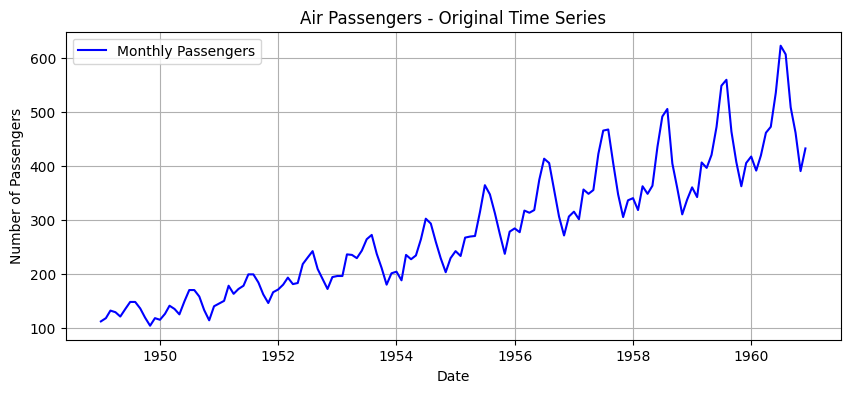

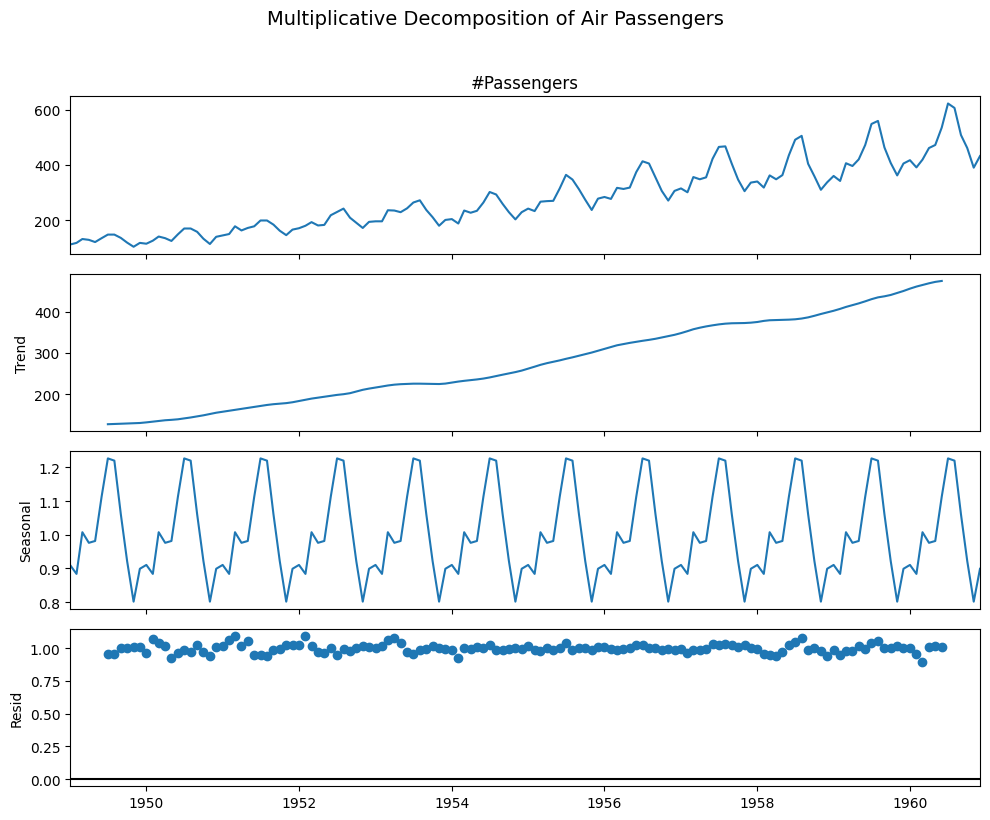

In [4]:
# Question 6. Dataset Load a time series dataset (e.g., AirPassengers), plot the original series,
#             and decompose it into trend, seasonality, and residual components

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load the AirPassengers dataset from the local Colab directory
file_path = '/content/AirPassengers.csv'
df = pd.read_csv(file_path, parse_dates=['Month'], index_col='Month')

# 2. Plot the original series
plt.figure(figsize=(10, 4))
plt.plot(df['#Passengers'], label='Monthly Passengers', color='blue')
plt.title('Air Passengers - Original Time Series')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

# 3. Decompose the time series (using multiplicative due to increasing variance)
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative', period=12)

# 4. Plot the decomposed components (Trend, Seasonality, Residuals)
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.suptitle('Multiplicative Decomposition of Air Passengers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

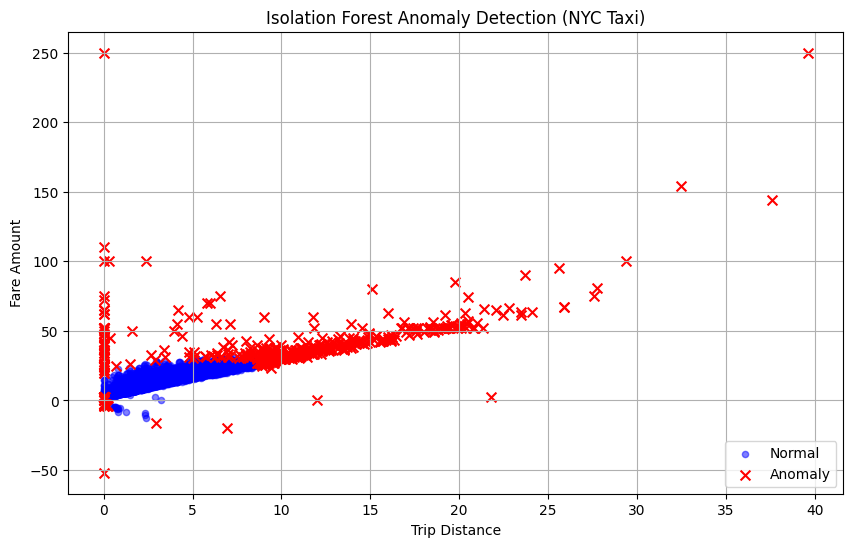

In [9]:
# Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
#             detect anomalies. Visualize the anomalies on a 2D scatter plot.

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# 1. Load the NYC Taxi Fare dataset
file_path = '/content/NYC_taxi_fare_data.csv'
df = pd.read_csv(file_path, nrows=10000)

# 2. Data Preprocessing
# Drop any rows with missing values
df = df.dropna()

# Yahan hume formula lagane ki zaroorat nahi hai kyunki 'trip_distance' pehle se hai
features = ['trip_distance', 'fare_amount']
X = df[features]

# 3. Apply Isolation Forest
# We set contamination to 0.05 (5% anomalies expected)
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model and predict anomalies (1 for normal, -1 for anomaly)
df['anomaly_label'] = iso_forest.fit_predict(X)

# 4. Visualize the anomalies on a 2D Scatter Plot
plt.figure(figsize=(10, 6))

# Plot normal points
plt.scatter(df[df['anomaly_label'] == 1]['trip_distance'],
            df[df['anomaly_label'] == 1]['fare_amount'],
            c='blue', label='Normal', alpha=0.5, s=20)

# Plot anomalies
plt.scatter(df[df['anomaly_label'] == -1]['trip_distance'],
            df[df['anomaly_label'] == -1]['fare_amount'],
            c='red', label='Anomaly', marker='x', s=50)

plt.title('Isolation Forest Anomaly Detection (NYC Taxi)')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.legend()
plt.grid(True)
plt.show()



Training SARIMA model...


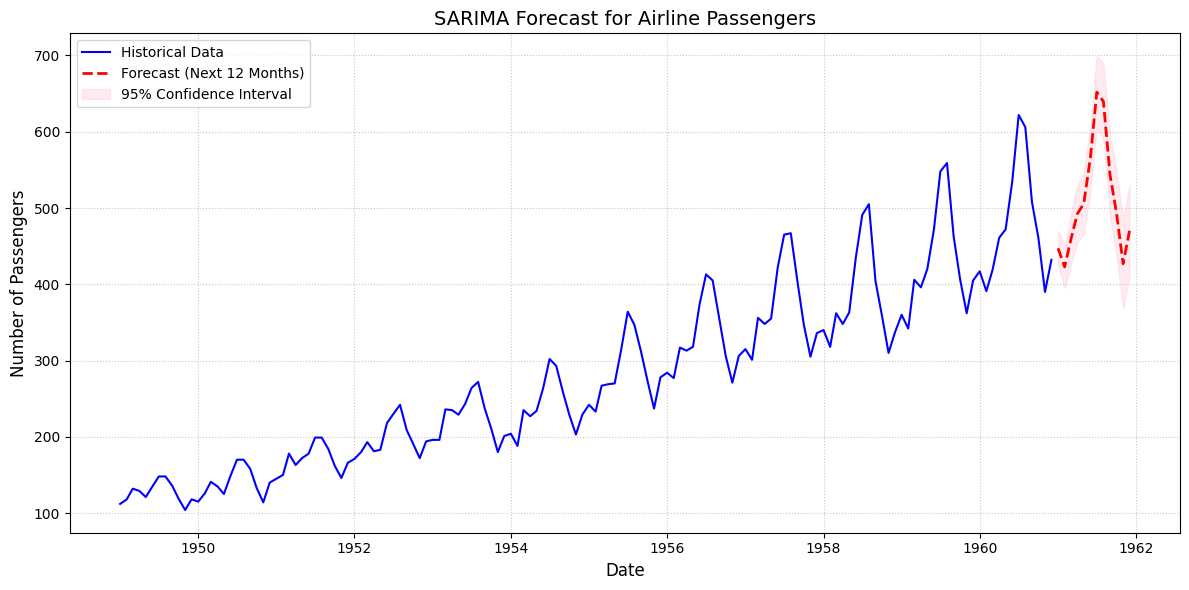


Forecasted Values for the next 12 months:
1961-01-01    447.0
1961-02-01    423.0
1961-03-01    458.0
1961-04-01    492.0
1961-05-01    506.0
1961-06-01    566.0
1961-07-01    652.0
1961-08-01    640.0
1961-09-01    543.0
1961-10-01    494.0
1961-11-01    427.0
1961-12-01    470.0
Freq: MS, Name: predicted_mean, dtype: float64


In [10]:
# Question 8: Train a SARIMA model on the monthly airline passengers dataset.
#             Forecast the next 12 months and visualize the results.

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Ignore harmless convergence warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. Load the AirPassengers dataset from the local Colab directory
file_path = '/content/AirPassengers.csv'
df = pd.read_csv(file_path, parse_dates=['Month'], index_col='Month')

# Dynamically select the correct column name based on your file
col_name = '#Passengers' if '#Passengers' in df.columns else 'Passengers'

# 2. Define and Train the SARIMA Model
# order = (p,d,q) for standard ARIMA
# seasonal_order = (P,D,Q,s) for seasonal components (s=12 for monthly data)
print("Training SARIMA model...")
model = SARIMAX(df[col_name],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)

# 3. Forecast the next 12 months
# get_forecast() calculates the predictions and the confidence intervals
forecast = results.get_forecast(steps=12)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# 4. Visualize the historical data and the forecast
plt.figure(figsize=(12, 6))

# Plot historical data
plt.plot(df.index, df[col_name], label='Historical Data', color='blue')

# Plot forecasted mean
plt.plot(predicted_mean.index, predicted_mean, label='Forecast (Next 12 Months)', color='red', linestyle='--', linewidth=2)

# Fill the confidence interval area (pink shading)
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='95% Confidence Interval')

# Formatting the plot
plt.title('SARIMA Forecast for Airline Passengers', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

# Display the plot
plt.show()

# Print the forecasted values
print("\nForecasted Values for the next 12 months:")
print(round(predicted_mean))


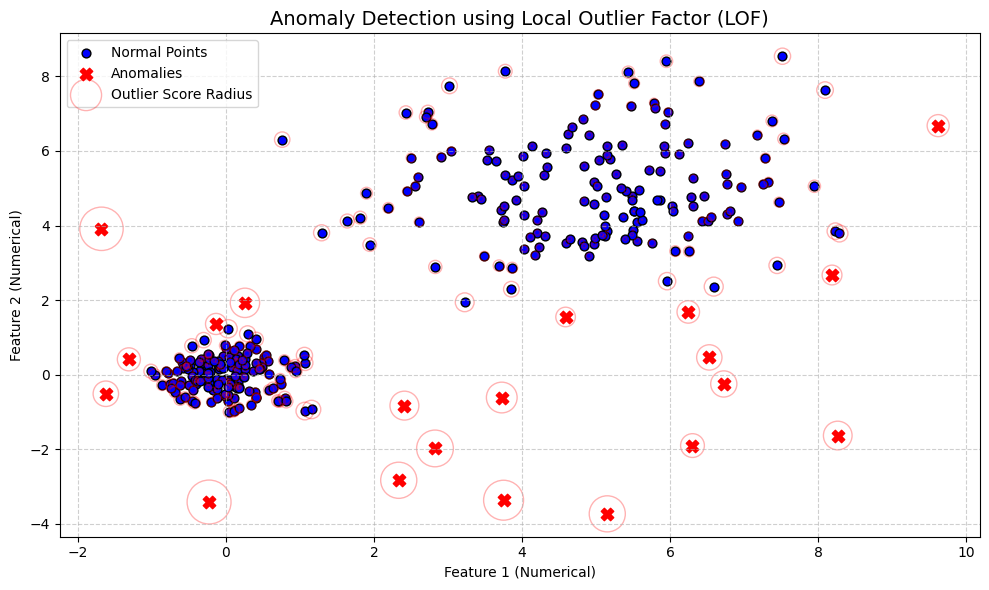

In [11]:
# Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect
#             anomalies and visualize them using matplotlib.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import make_blobs

# 1. Generate a synthetic numerical dataset
# Creating two normal clusters with DIFFERENT densities (cluster_std)
X_inliers, _ = make_blobs(n_samples=300, centers=[[0, 0], [5, 5]],
                          cluster_std=[0.5, 1.5], random_state=42)

# Generate some random, uniform outliers
X_outliers = np.random.uniform(low=-4, high=9, size=(20, 2))

# Combine them into a single dataset
X = np.vstack([X_inliers, X_outliers])

# 2. Apply Local Outlier Factor (LOF)
# n_neighbors: number of neighbors to consider for local density (20 is standard)
# contamination: the expected percentage of outliers in the dataset
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.06)

# Fit the model and predict labels (-1 for anomalies, 1 for normal points)
y_pred = lof.fit_predict(X)

# LOF calculates a score for how "outlier-ish" a point is.
# We extract these to draw visual circles around the points later.
X_scores = lof.negative_outlier_factor_

# 3. Visualize the results using matplotlib
plt.figure(figsize=(10, 6))

# Plot normal points (predicted as 1)
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1],
            c='blue', label='Normal Points', edgecolor='k', s=40)

# Plot anomalies (predicted as -1)
plt.scatter(X[y_pred == -1, 0], X[y_pred == -1, 1],
            c='red', label='Anomalies', marker='X', s=80)

# Visual Bonus: Draw circles showing the outlier scores
# (Larger red circle = higher outlier score)
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
plt.scatter(X[:, 0], X[:, 1], s=1000 * radius, edgecolors='red',
            facecolors='none', alpha=0.3, label='Outlier Score Radius')

# Formatting the plot
plt.title('Anomaly Detection using Local Outlier Factor (LOF)', fontsize=14)
plt.xlabel('Feature 1 (Numerical)')
plt.ylabel('Feature 2 (Numerical)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()


Question 10: You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.
  - --->> Explain your real-time data science workflow:
  - 1 .● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
  - 2.● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?
  - 3.● How would you validate and monitor the performance over time?
  - 4.● How would this solution help business decisions or operations?

1. Anomaly Detection:
   - Isolation Forest (with Sliding Window)For a real-time, streaming 15-minute interval dataset, Isolation Forest is the most practical and efficient choice among the three.
  - Why not DBSCAN?
    - DBSCAN struggles with varying densities and is computationally expensive for high-frequency streaming data.
  - Why not LOF?
    - While LOF is great for finding local anomalies, it requires computing distances to neighbors, which is computationally heavy ($O(n^2)$) and too slow to execute every 15 minutes as new data pours in.
  - Why Isolation Forest?
    - It has a low time complexity ($O(n)$) and handles multivariate data (energy usage + weather + time) exceptionally well.
  - The Streaming Workflow:
    - Since true Isolation Forest requires a static dataset, I would implement a sliding window approach. The model trains on a rolling window (e.g., the last 7 or 30 days) and scores incoming 15-minute data points in real-time. If the anomaly score breaches a dynamic threshold, an alert is triggered.

2. Short-Term Forecasting: SARIMAX
  - I would unequivocally choose SARIMAX (Seasonal Auto-Regressive Integrated Moving Average with eXogenous factors).

  - Why SARIMAX?
    - Energy demand is entirely driven by two things: Time and Weather.
  - Seasonality (The "S" and "ARIMA"):
    - Energy usage has strict repeating patterns. People wake up, turn on lights, go to work, and come home at roughly the same time every day (daily seasonality). Usage also changes between weekdays and weekends (weekly seasonality).
  - Exogenous Variables (The "X"):
    - Energy spikes are heavily dependent on external features like temperature (heaters in winter, AC in summer) and humidity.

3. Validation and Monitoring Performance
  - Because time is a factor, we cannot use standard random train/test splits.

  - Initial Validation (Offline):
    - I would use Time-Series Cross-Validation (Walk-Forward Validation). We train the model on past data (e.g., Jan-Mar), test on the next block (Apr), then expand the training set (Jan-Apr) and test on the next (May). We evaluate the forecast using metrics like MAPE (Mean Absolute Percentage Error) and RMSE (Root Mean Squared Error).

  - Real-Time Monitoring (Online):
    - Track Residuals: I would monitor the forecast errors (residuals). If the errors consistently skew in one direction (e.g., we are constantly under-predicting demand), it indicates Concept Drift (e.g., consumers bought more electric vehicles, raising the baseline).
  - Alert Fatigue:
    - For anomalies, monitor the false-positive rate. If operators are getting 50 alerts an hour, they will ignore them. The threshold must be tuned to flag only critical spikes/drops.
  - Automated Retraining:
    - Set up a pipeline to automatically retrain the SARIMAX and Isolation Forest models weekly to capture the latest baseline behaviors.

4. Business Impact and Operational Value
  - Deploying this dual forecasting and anomaly detection system drives massive value for the power company:

  - Grid Stability & Load Balancing (Forecast):
    - By knowing exactly how much power will be needed in the next 24 hours, the grid operators can spin up secondary power plants or route energy to high-demand regions before a surge happens, preventing brownouts or blackouts.
  - Cost Efficiency (Forecast):
    - Power companies often have to buy emergency energy from neighboring grids at massive markups if they run short. Accurate forecasting prevents these expensive, last-minute purchases.
  - Immediate Fault Detection (Anomaly):
    - A sudden, localized drop in energy consumption flagged by the Isolation Forest could indicate a blown transformer or a severed line. Repair crews can be dispatched immediately, even before customers call to complain.
  - Theft Detection (Anomaly):
    - A slow but continuous abnormal spike in a specific sector could indicate illegal power tapping or a malfunctioning commercial meter, saving the company from unbilled losses.